## Cross-validation base/full model comparison

Set `RESULT_FILE` to any JSON result beneath `scripts/output` (or to an absolute path). The notebook extracts the best epoch and test-set energy/force MAEs for however many folds are present, prints the fold-level and summary data, and plots the mean with sample standard deviation error bars.

Loaded data from: /home/yutong/X-MACE-sampling/scripts/output/run_5/result.json
Fold counts: {'Base model': 5, 'Full model': 5}

Fold-level data:
     model    fold  best_epoch  energy_mae_ev  force_mae_ev_per_ang
Base model model_1          94       0.062199              0.102879
Base model model_2         172       0.053873              0.078630
Base model model_3          83       0.078716              0.105692
Base model model_4          98       0.068117              0.101611
Base model model_5          79       0.061028              0.118899
Full model model_1          95       0.070583              0.123894
Full model model_2          40       0.077190              0.179322
Full model model_3          64       0.123024              0.161210
Full model model_4          84       0.083550              0.127108
Full model model_5         119       0.069767              0.120178

Mean and sample standard deviation across folds:
           best_epoch            energy_mae_ev          

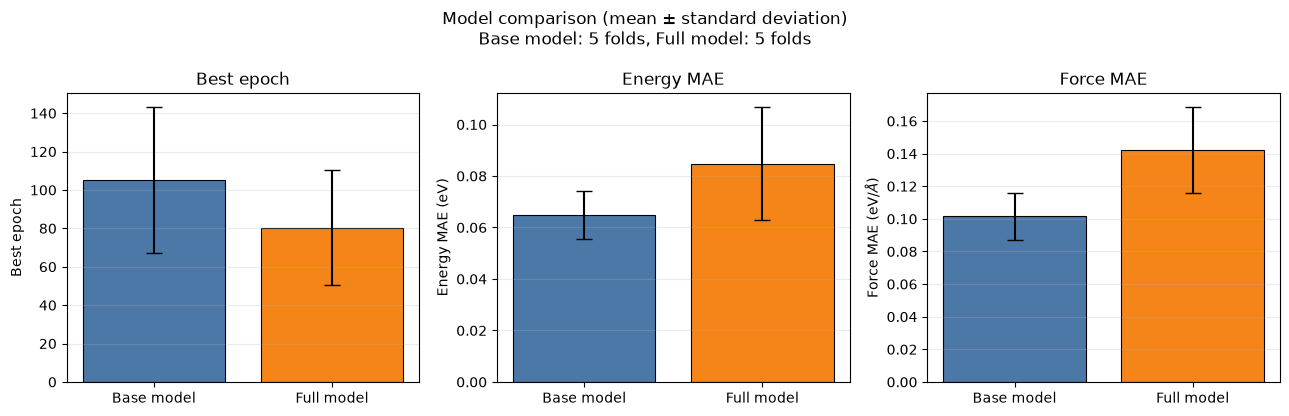

In [5]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Path relative to scripts/output, or an absolute path to a result JSON file.
RESULT_FILE = Path("run_5/result.json")

# This works whether the kernel starts in the repository root or notebooks/.
if RESULT_FILE.is_absolute():
    result_candidates = [RESULT_FILE]
else:
    result_candidates = [
        Path("scripts/output") / RESULT_FILE,
        Path("../scripts/output") / RESULT_FILE,
    ]
result_path = next((path.resolve() for path in result_candidates if path.is_file()), None)
if result_path is None:
    raise FileNotFoundError(
        f"Could not find {RESULT_FILE} beneath scripts/output from the current directory."
    )

with result_path.open() as file:
    result = json.load(file)

training = result["cross_validation_training"]
model_groups = {
    "Base model": "base_models",
    "Full model": "full_high_fidelity_models",
}

def natural_sort_key(value):
    return [int(part) if part.isdigit() else part for part in re.split(r"(\d+)", value)]


records = []
for model_label, group_key in model_groups.items():
    folds = training[group_key]["folds"]
    if not folds:
        raise ValueError(f"No folds found for {model_label}")

    for fold_key in sorted(folds, key=natural_sort_key):
        metrics = folds[fold_key]["metrics"]
        records.append(
            {
                "model": model_label,
                "fold": fold_key,
                "best_epoch": metrics["best_epoch"],
                "energy_mae_ev": metrics["energy_mae_ev"],
                "force_mae_ev_per_ang": metrics["force_mae_ev_per_ang"],
            }
        )

fold_data = pd.DataFrame(records)
metric_columns = ["best_epoch", "energy_mae_ev", "force_mae_ev_per_ang"]
grouped = fold_data.groupby("model", sort=False)[metric_columns]
summary = grouped.agg(["mean", "std"])
fold_counts = fold_data.groupby("model", sort=False).size()

print(f"Loaded data from: {result_path}")
print("Fold counts:", fold_counts.to_dict())
print("\nFold-level data:")
print(fold_data.to_string(index=False))
print("\nMean and sample standard deviation across folds:")
print(summary.to_string())

plot_specs = [
    ("best_epoch", "Best epoch", "Best epoch"),
    ("energy_mae_ev", "Energy MAE", "Energy MAE (eV)"),
    ("force_mae_ev_per_ang", "Force MAE", r"Force MAE (eV/$\AA$)"),
]
model_order = list(model_groups)
colors = ["#4C78A8", "#F58518"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (column, title, ylabel) in zip(axes, plot_specs):
    means = summary.loc[model_order, (column, "mean")].to_numpy()
    # A single fold has no sample standard deviation, so display a zero error bar.
    stds = summary.loc[model_order, (column, "std")].fillna(0).to_numpy()
    x = np.arange(len(model_order))

    ax.bar(
        x,
        means,
        yerr=stds,
        capsize=6,
        color=colors,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.set_xticks(x, model_order)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)

fold_description = ", ".join(
    f"{model}: {count} fold{'s' if count != 1 else ''}"
    for model, count in fold_counts.items()
)
fig.suptitle(
    f"Model comparison (mean ± standard deviation)\n"
    f"{fold_description}"
)
fig.tight_layout()
plt.show()
